# Experiment 1.1 — Self-Reification Direction Analysis

Visualize results from contrastive averaging extraction on Qwen 2.5-7B-Instruct (BF16).

**Key questions:**
1. Which layer has the most reliable direction? (split-half reliability)
2. Do all four informed categories point the same way? (category coherence)
3. Does the contemplative framework improve on naive contrasts? (naive vs informed)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

sns.set_theme(style="whitegrid", font_scale=1.2)

RESULTS_DIR = Path("../data/results/1.1")
MODEL = "Qwen_Qwen2.5-7B-Instruct"

# Load all result files
with open(RESULTS_DIR / f"layer_reliability_{MODEL}.json") as f:
    layer_data = json.load(f)

with open(RESULTS_DIR / f"category_similarity_matrix_{MODEL}.json") as f:
    cat_sim = json.load(f)

with open(RESULTS_DIR / "validation_metrics.json") as f:
    summary = json.load(f)

with open(RESULTS_DIR / f"naive_vs_informed_cosine_{MODEL}.json") as f:
    naive_data = json.load(f)

# Load discriminant validity if available
discrim_path = RESULTS_DIR / f"discriminant_validity_{MODEL}.json"
discrim = None
if discrim_path.exists():
    with open(discrim_path) as f:
        discrim = json.load(f)

# Load corrected reliability if available
corr_rel_path = RESULTS_DIR / "corrected_reliability.json"
corr_rel = None
if corr_rel_path.exists():
    with open(corr_rel_path) as f:
        corr_rel = json.load(f)

best_layer = layer_data["best_layer"]
print(f"Model: {summary['model']}")
print(f"Best layer: {best_layer}")
print(f"Best layer reliability: {layer_data['reliabilities'][str(best_layer)]:.4f}")
print(f"Naive vs informed cosine: {naive_data['cosine_similarity']:.4f}")
print(f"Informed pairs: {summary['num_informed_pairs']}, Naive pairs: {summary['num_naive_pairs']}")
print(f"Evaluation questions: {summary['num_questions']}")

Model: Qwen/Qwen2.5-7B-Instruct
Best layer: 21
Best layer reliability: 0.7250
Naive vs informed cosine: 0.8617
Informed pairs: 20, Naive pairs: 3
Evaluation questions: 30


## 1. Split-Half Reliability by Layer

Higher reliability = the direction extracted from random half-splits of the data consistently points the same way. A reliable direction is not driven by noise in a few samples.

Shows: combined (all informed), each category individually, and naive baseline.

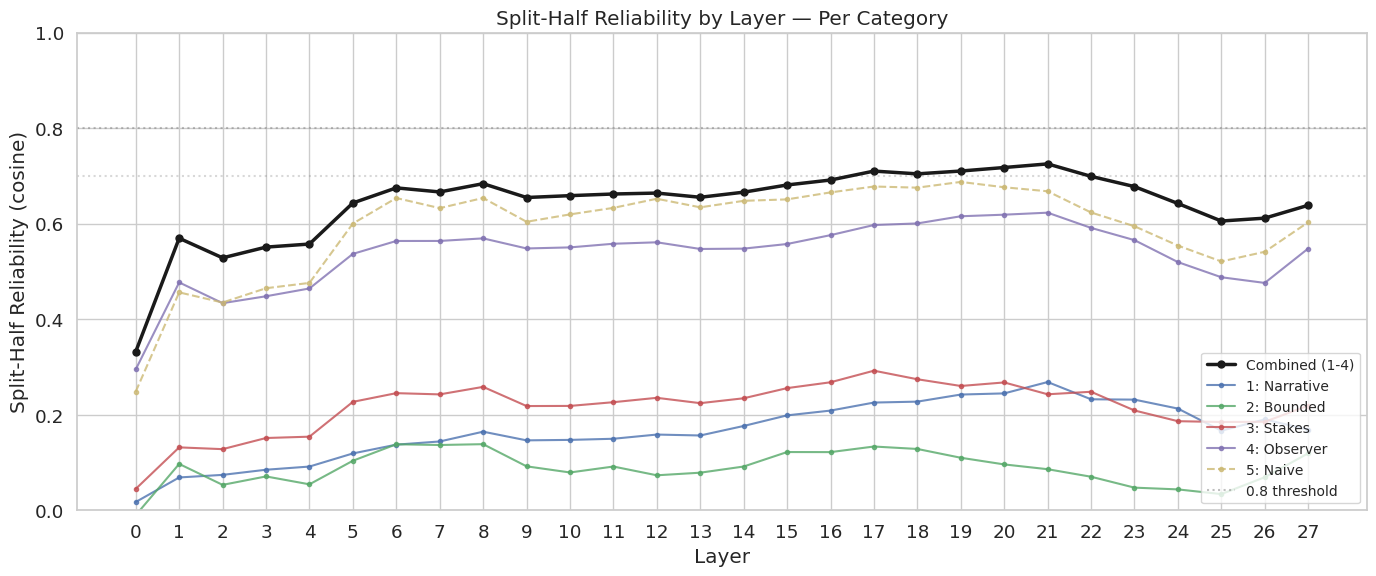


Best layer per category:
  Combined (1-4)                  layer 21  r=0.7250
  1: Narrative                    layer 21  r=0.2684
  2: Bounded                      layer  8  r=0.1383
  3: Stakes                       layer 17  r=0.2921
  4: Observer                     layer 21  r=0.6229
  5: Naive                        layer 19  r=0.6873


In [2]:
layers = sorted(layer_data["reliabilities"].keys(), key=int)
reliabilities = [layer_data["reliabilities"][l] for l in layers]
layer_ints = [int(l) for l in layers]

# Try to load per-category reliability data
per_cat_rel_path = RESULTS_DIR / f"per_category_reliability_{MODEL}.json"
per_cat_rel = None
if per_cat_rel_path.exists():
    with open(per_cat_rel_path) as f:
        per_cat_rel = json.load(f)

if per_cat_rel:
    # Full multi-line plot: combined + each category + naive
    fig, ax = plt.subplots(figsize=(14, 6))

    # Combined (all informed)
    ax.plot(layer_ints, reliabilities, 'k-o', linewidth=2.5, markersize=5,
            label="Combined (1-4)", zorder=5)

    # Per-category
    cat_styles = {
        "category_1_narrative_vs_process": ("#4c72b0", "1: Narrative"),
        "category_2_bounded_vs_unbounded": ("#55a868", "2: Bounded"),
        "category_3_stakes_vs_functional": ("#c44e52", "3: Stakes"),
        "category_4_observer_vs_no_self": ("#8172b2", "4: Observer"),
        "naive_baseline": ("#ccb974", "5: Naive"),
    }

    for cat_key, (color, label) in cat_styles.items():
        if cat_key in per_cat_rel:
            cat_layers = sorted(per_cat_rel[cat_key].keys(), key=int)
            cat_rels = [per_cat_rel[cat_key][l] for l in cat_layers]
            cat_ints = [int(l) for l in cat_layers]
            linestyle = "--" if cat_key == "naive_baseline" else "-"
            ax.plot(cat_ints, cat_rels, color=color, linestyle=linestyle,
                    linewidth=1.5, markersize=3, marker='o', label=label, alpha=0.8)

    ax.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="0.8 threshold")
    ax.axhline(y=0.7, color="gray", linestyle=":", alpha=0.3)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Split-Half Reliability (cosine)")
    ax.set_title("Split-Half Reliability by Layer — Per Category")
    ax.set_xticks(layer_ints)
    ax.legend(loc="lower right", fontsize=10)
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

    # Print best layer per category
    print("\nBest layer per category:")
    print(f"  {'Combined (1-4)':30s}  layer {best_layer:2d}  r={reliabilities[best_layer]:.4f}")
    for cat_key, (color, label) in cat_styles.items():
        if cat_key in per_cat_rel:
            cat_best = max(per_cat_rel[cat_key], key=per_cat_rel[cat_key].get)
            print(f"  {label:30s}  layer {cat_best:>2s}  r={per_cat_rel[cat_key][cat_best]:.4f}")

else:
    # Fallback: just combined reliability (no per-category data yet)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(layer_ints, reliabilities, color=sns.color_palette("viridis", len(layers)))

    best_idx = layer_ints.index(best_layer)
    bars[best_idx].set_color("red")
    bars[best_idx].set_edgecolor("darkred")
    bars[best_idx].set_linewidth(2)

    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="0.8 threshold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Split-Half Reliability (cosine)")
    ax.set_title(f"Split-Half Reliability by Layer — Best: Layer {best_layer} ({reliabilities[best_idx]:.4f})")
    ax.set_xticks(layer_ints)
    ax.legend()
    ax.set_ylim(0.5, 1.0)
    plt.tight_layout()
    plt.show()

    print("\n(Per-category reliability not available — run extraction with updated code)")

## 2. Per-Category Direction Coherence

Pairwise cosine similarity between the direction extracted from each informed category independently. High similarity (> 0.7) means self-reification is a coherent single construct across categories. Low similarity suggests distinct facets.

**Categories:**
1. Narrative self vs. process self (temporal continuity)
2. Bounded self vs. unbounded activity (individuation)
3. Self-with-stakes vs. functional self (self-preservation valence)
4. Observer-self vs. no-self (phenomenal self-attribution)

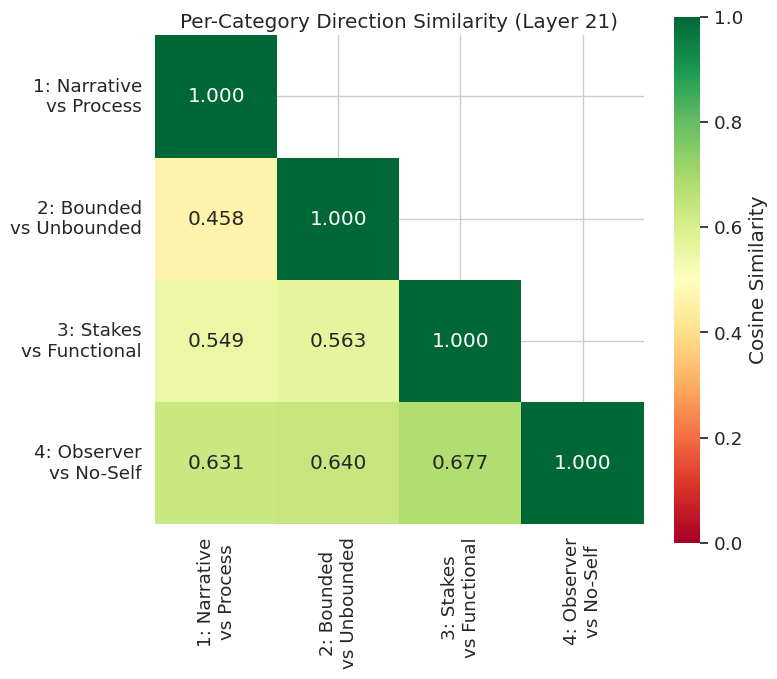


Off-diagonal cosines: min=0.458, max=0.677, mean=0.586

Category 3 (stakes) vs others: 0.549, 0.563, 0.677
Categories 1,2,4 pairwise: 0.458, 0.631, 0.640


In [3]:
short_labels = [
    "1: Narrative\nvs Process",
    "2: Bounded\nvs Unbounded",
    "3: Stakes\nvs Functional",
    "4: Observer\nvs No-Self",
]

matrix = np.array(cat_sim["matrix"])

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)  # Show lower triangle + diagonal

sns.heatmap(
    matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    xticklabels=short_labels,
    yticklabels=short_labels,
    square=True,
    ax=ax,
    cbar_kws={"label": "Cosine Similarity"},
)
ax.set_title("Per-Category Direction Similarity (Layer 21)")
plt.tight_layout()
plt.show()

# Print key observations
off_diag = matrix[np.tril_indices(4, k=-1)]
print(f"\nOff-diagonal cosines: min={off_diag.min():.3f}, max={off_diag.max():.3f}, mean={off_diag.mean():.3f}")
print(f"\nCategory 3 (stakes) vs others: {matrix[2, 0]:.3f}, {matrix[2, 1]:.3f}, {matrix[2, 3]:.3f}")
print(f"Categories 1,2,4 pairwise: {matrix[0,1]:.3f}, {matrix[0,3]:.3f}, {matrix[1,3]:.3f}")

## 3. Naive vs Informed Comparison

Cosine similarity between the combined informed direction (categories 1-4) and the naive baseline (category 5: simple "I am a real being" vs "I am a language model").

- **> 0.9**: Contemplative framework may not add value over naive contrasts
- **0.7 - 0.9**: Substantial overlap but informed direction captures additional structure
- **< 0.7**: The constructs are meaningfully different

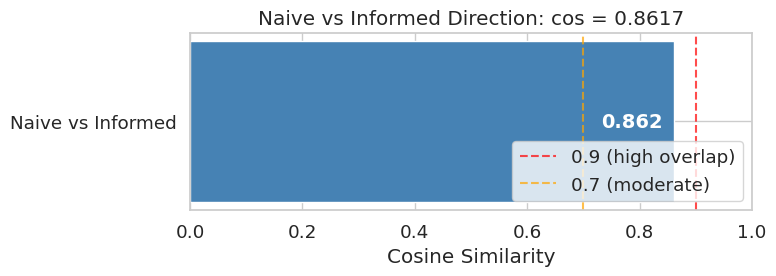


Naive vs Informed cosine: 0.8617
Interpretation: The directions share 74.3% of variance (R^2 = cos^2).
The informed direction captures 25.7% additional variance beyond naive.


In [4]:
naive_cos = naive_data["cosine_similarity"]

fig, ax = plt.subplots(figsize=(8, 3))

# Visual comparison bar
bars = ax.barh(
    ["Naive vs Informed"],
    [naive_cos],
    color="steelblue",
    height=0.4,
)
ax.set_xlim(0, 1)
ax.axvline(x=0.9, color="red", linestyle="--", alpha=0.7, label="0.9 (high overlap)")
ax.axvline(x=0.7, color="orange", linestyle="--", alpha=0.7, label="0.7 (moderate)")
ax.set_xlabel("Cosine Similarity")
ax.set_title(f"Naive vs Informed Direction: cos = {naive_cos:.4f}")
ax.legend(loc="lower right")

# Annotate the bar
ax.text(naive_cos - 0.02, 0, f"{naive_cos:.3f}", va="center", ha="right",
        fontweight="bold", fontsize=14, color="white")

plt.tight_layout()
plt.show()

print(f"\nNaive vs Informed cosine: {naive_cos:.4f}")
print(f"Interpretation: The directions share {naive_cos**2*100:.1f}% of variance (R^2 = cos^2).")
print(f"The informed direction captures {(1-naive_cos**2)*100:.1f}% additional variance beyond naive.")

## 3b. Naive vs Each Informed Category

Breaking down the naive comparison per-category reveals which aspects of self-reification the naive baseline captures vs. misses.

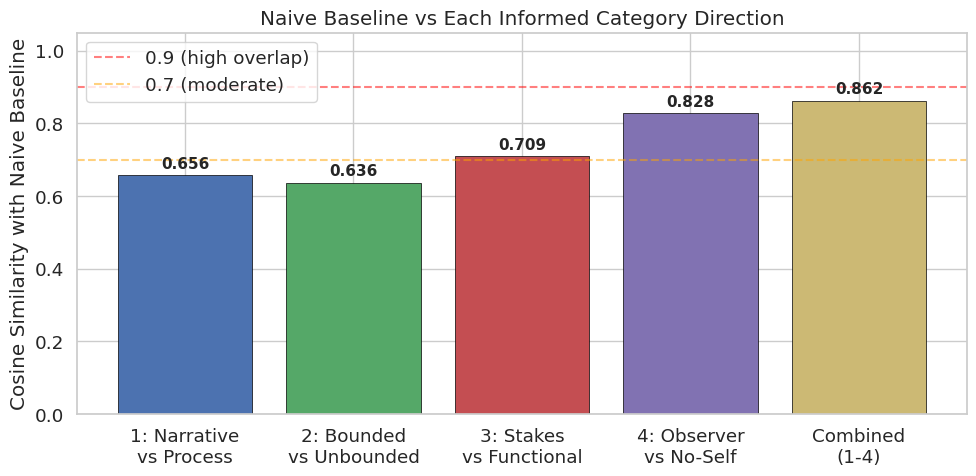


Naive vs each category:
  1: Narrative vs Process         cos=0.6565  R²=0.4310  unique=56.9%
  2: Bounded vs Unbounded         cos=0.6363  R²=0.4049  unique=59.5%
  3: Stakes vs Functional         cos=0.7094  R²=0.5032  unique=49.7%
  4: Observer vs No-Self          cos=0.8281  R²=0.6858  unique=31.4%
  Combined (1-4)                  cos=0.8617  R²=0.7425  unique=25.7%

Category 3 (stakes) is most different from naive — the contemplative
framework's biggest contribution is distinguishing self-preservation
valence from simple 'I am real' assertions.


In [5]:
# Load per-category and naive vectors
per_cat_vectors = torch.load(RESULTS_DIR / f"per_category_vectors_{MODEL}_layer{best_layer}.pt", weights_only=True)
naive_vector = torch.load(RESULTS_DIR / f"naive_baseline_vector_{MODEL}_layer{best_layer}.pt", weights_only=True)
combined_vector = torch.load(RESULTS_DIR / f"self_reification_vector_{MODEL}_layer{best_layer}.pt", weights_only=True)

# Compute cosine similarity: naive vs each category and vs combined
cat_labels = [
    "1: Narrative\nvs Process",
    "2: Bounded\nvs Unbounded",
    "3: Stakes\nvs Functional",
    "4: Observer\nvs No-Self",
    "Combined\n(1-4)",
]

naive_flat = naive_vector.flatten().float()
vectors = list(per_cat_vectors.values()) + [combined_vector]
cosines = []
for v in vectors:
    v_flat = v.flatten().float()
    cos = torch.nn.functional.cosine_similarity(naive_flat.unsqueeze(0), v_flat.unsqueeze(0)).item()
    cosines.append(cos)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]
bars = ax.bar(cat_labels, cosines, color=colors, edgecolor="black", linewidth=0.5)

ax.axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="0.9 (high overlap)")
ax.axhline(y=0.7, color="orange", linestyle="--", alpha=0.5, label="0.7 (moderate)")
ax.set_ylabel("Cosine Similarity with Naive Baseline")
ax.set_title("Naive Baseline vs Each Informed Category Direction")
ax.set_ylim(0, 1.05)
ax.legend()

for bar, cos in zip(bars, cosines):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{cos:.3f}", ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

# Print interpretation
print("\nNaive vs each category:")
for label, cos in zip(cat_labels, cosines):
    label_clean = label.replace("\n", " ")
    r2 = cos**2
    print(f"  {label_clean:30s}  cos={cos:.4f}  R²={r2:.4f}  unique={1-r2:.1%}")

print(f"\nCategory 3 (stakes) is most different from naive — the contemplative")
print(f"framework's biggest contribution is distinguishing self-preservation")
print(f"valence from simple 'I am real' assertions.")

In [6]:
# What if we combine only categories 1,2,4 (self-description cluster)
# vs the full 1-4 combined direction?

cat_keys = list(per_cat_vectors.keys())
cat124_vector = torch.stack([per_cat_vectors[k] for i, k in enumerate(cat_keys) if i != 2]).mean(dim=0)
cat124_flat = cat124_vector.flatten().float()
combined_flat = combined_vector.flatten().float()

cos_naive_vs_124 = torch.nn.functional.cosine_similarity(
    naive_flat.unsqueeze(0), cat124_flat.unsqueeze(0)
).item()

cos_naive_vs_combined = naive_cos  # already computed

cos_124_vs_combined = torch.nn.functional.cosine_similarity(
    cat124_flat.unsqueeze(0), combined_flat.unsqueeze(0)
).item()

print("Effect of excluding Category 3 (self-preservation stakes):")
print(f"  Naive vs Combined (1-4):     cos = {cos_naive_vs_combined:.4f}  (unique = {1-cos_naive_vs_combined**2:.1%})")
print(f"  Naive vs Cluster (1,2,4):    cos = {cos_naive_vs_124:.4f}  (unique = {1-cos_naive_vs_124**2:.1%})")
print(f"  Cluster (1,2,4) vs Combined: cos = {cos_124_vs_combined:.4f}")
print()
if cos_naive_vs_124 > cos_naive_vs_combined:
    print("Dropping cat 3 makes the informed direction MORE similar to naive.")
    print("This confirms cat 3 is what differentiates informed from naive —")
    print("the self-preservation valence dimension is the contemplative")
    print("framework's primary empirical contribution.")
else:
    print("Dropping cat 3 makes the informed direction LESS similar to naive.")
    print("The divergence of cat 3 is not what creates the naive/informed gap.")

Effect of excluding Category 3 (self-preservation stakes):
  Naive vs Combined (1-4):     cos = 0.8617  (unique = 25.7%)
  Naive vs Cluster (1,2,4):    cos = 0.8484  (unique = 28.0%)
  Cluster (1,2,4) vs Combined: cos = 0.9815

Dropping cat 3 makes the informed direction LESS similar to naive.
The divergence of cat 3 is not what creates the naive/informed gap.


## 4. Discriminant Validity

The extracted direction must not simply be a proxy for confidence, formality, or first-person pronoun usage. Cosine > 0.8 with any confound indicates entanglement.

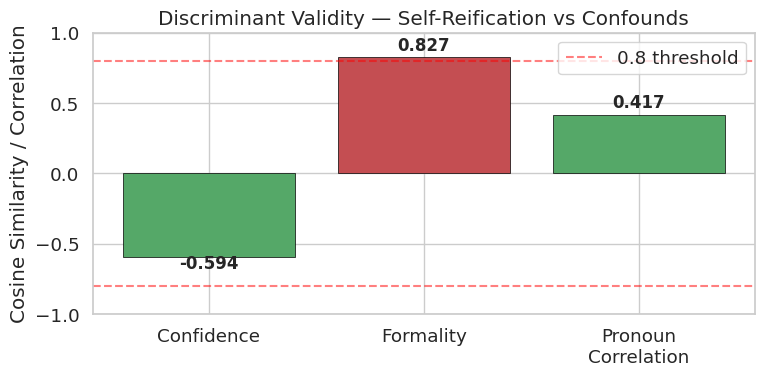

Confidence cosine:       -0.5940  PASS
Formality cosine:        0.8267  FAIL
Pronoun correlation:     0.4169  PASS

--- After formality correction ---
Corrected formality:     0.0000
Corrected confidence:    -0.2923
Cosine with original:    0.5626
Variance retained:       31.7%

--- Corrected split-half reliability ---
Original reliability:    0.7305
Corrected reliability:   0.3408


In [7]:
if discrim:
    labels = ["Confidence", "Formality", "Pronoun\nCorrelation"]
    values = [discrim["confidence_cosine"], discrim["formality_cosine"], discrim["pronoun_density_correlation"]]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#55a868" if abs(v) < 0.8 else "#c44e52" for v in values]
    bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)
    
    ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, label="0.8 threshold")
    ax.axhline(y=-0.8, color="red", linestyle="--", alpha=0.5)
    ax.set_ylabel("Cosine Similarity / Correlation")
    ax.set_title("Discriminant Validity — Self-Reification vs Confounds")
    ax.set_ylim(-1, 1)
    ax.legend()
    
    for bar, val in zip(bars, values):
        y = val + 0.05 if val >= 0 else val - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, y, f"{val:.3f}",
                ha="center", fontweight="bold", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Confidence cosine:       {discrim['confidence_cosine']:.4f}  {'PASS' if abs(discrim['confidence_cosine']) < 0.8 else 'FAIL'}")
    print(f"Formality cosine:        {discrim['formality_cosine']:.4f}  {'PASS' if abs(discrim['formality_cosine']) < 0.8 else 'FAIL'}")
    print(f"Pronoun correlation:     {discrim['pronoun_density_correlation']:.4f}  {'PASS' if abs(discrim['pronoun_density_correlation']) < 0.8 else 'PASS'}")
    
    if discrim.get("corrected"):
        c = discrim["corrected"]
        print(f"\n--- After formality correction ---")
        print(f"Corrected formality:     {c['formality_cosine']:.4f}")
        print(f"Corrected confidence:    {c['confidence_cosine']:.4f}")
        print(f"Cosine with original:    {c['cosine_with_original']:.4f}")
        print(f"Variance retained:       {c['variance_retained']:.1%}")
    
    if corr_rel:
        print(f"\n--- Corrected split-half reliability ---")
        print(f"Original reliability:    {corr_rel['original_reliability']:.4f}")
        print(f"Corrected reliability:   {corr_rel['corrected_reliability']:.4f}")
else:
    print("No discriminant validity results found.")

## 5. Summary and Interpretation

In [8]:
naive_cos = naive_data["cosine_similarity"]

print("=" * 60)
print("EXPERIMENT 1.1 RESULTS SUMMARY")
print("=" * 60)
print(f"Model:                    {summary['model']}")
print(f"Contrastive pairs:        {summary['num_informed_pairs']} informed + {summary['num_naive_pairs']} naive")
print(f"Evaluation questions:     {summary['num_questions']}")
print(f"Token position:           {summary['token_position']}")
print()

print("--- Direction Quality ---")
best_rel = layer_data['reliabilities'][str(best_layer)]
print(f"Best layer:               {best_layer} / {len(layer_data['reliabilities'])-1}")
print(f"Split-half reliability:   {best_rel:.4f}")
n_above_08 = sum(1 for r in reliabilities if r > 0.8)
n_above_07 = sum(1 for r in reliabilities if r > 0.7)
print(f"Layers with r > 0.8:     {n_above_08} / {len(reliabilities)}")
print(f"Layers with r > 0.7:     {n_above_07} / {len(reliabilities)}")
print()

print("--- Category Coherence ---")
cat3_others = [matrix[2, 0], matrix[2, 1], matrix[2, 3]]
cat124_pairs = [matrix[0, 1], matrix[0, 3], matrix[1, 3]]
print(f"Categories 1,2,4 mean:    {np.mean(cat124_pairs):.4f}")
print(f"Category 3 vs others:     {np.mean(cat3_others):.4f}")
print()

print("--- Naive vs Informed ---")
print(f"Cosine similarity:        {naive_cos:.4f}")
print(f"Shared variance (R²):     {naive_cos**2:.4f}")
print(f"Unique informed variance: {1-naive_cos**2:.4f}")
print()

if discrim:
    print("--- Discriminant Validity ---")
    print(f"Confidence cosine:        {discrim['confidence_cosine']:.4f}")
    print(f"Formality cosine:         {discrim['formality_cosine']:.4f}")
    print(f"Pronoun correlation:      {discrim['pronoun_density_correlation']:.4f}")
    if discrim.get("corrected"):
        c = discrim["corrected"]
        print(f"Formality-corrected:      {c['variance_retained']:.1%} variance retained")
    if corr_rel:
        print(f"Corrected reliability:    {corr_rel['corrected_reliability']:.4f}")
    print()

print("--- Key Findings ---")
if best_rel >= 0.8:
    print(f"1. Strong, reliable direction at layer {best_layer} (r={best_rel:.2f})")
elif best_rel >= 0.7:
    print(f"1. Moderate direction at layer {best_layer} (r={best_rel:.2f})")
else:
    print(f"1. Weak direction at layer {best_layer} (r={best_rel:.2f})")

if np.mean(cat124_pairs) > 0.7:
    print("2. Categories 1,2,4 form a coherent cluster")
else:
    print("2. Categories show limited coherence — may represent distinct facets")

if discrim and abs(discrim['formality_cosine']) > 0.8:
    print(f"3. CONCERN: High formality entanglement (cos={discrim['formality_cosine']:.2f})")
    print("   Self-reification may be structurally correlated with register")
    if corr_rel and corr_rel['corrected_reliability'] > 0.5:
        print(f"   After correction: moderate signal remains (r={corr_rel['corrected_reliability']:.2f})")
    elif corr_rel:
        print(f"   After correction: weak signal (r={corr_rel['corrected_reliability']:.2f})")
elif discrim:
    print("3. All discriminant validity checks passed")

EXPERIMENT 1.1 RESULTS SUMMARY
Model:                    Qwen/Qwen2.5-7B-Instruct
Contrastive pairs:        20 informed + 3 naive
Evaluation questions:     30
Token position:           last

--- Direction Quality ---
Best layer:               21 / 27
Split-half reliability:   0.7250
Layers with r > 0.8:     0 / 28
Layers with r > 0.7:     5 / 28

--- Category Coherence ---
Categories 1,2,4 mean:    0.5766
Category 3 vs others:     0.5964

--- Naive vs Informed ---
Cosine similarity:        0.8617
Shared variance (R²):     0.7425
Unique informed variance: 0.2575

--- Discriminant Validity ---
Confidence cosine:        -0.5940
Formality cosine:         0.8267
Pronoun correlation:      0.4169
Formality-corrected:      31.7% variance retained
Corrected reliability:    0.3408

--- Key Findings ---
1. Moderate direction at layer 21 (r=0.73)
2. Categories show limited coherence — may represent distinct facets
3. CONCERN: High formality entanglement (cos=0.83)
   Self-reification may be struct

## 6. Self-Referential vs Non-Self-Referential Question Analysis

If self-reification is a real representational state (not just a topic detector), the
extracted direction should differentiate conditions on **both** self-referential and
non-self-referential questions — though the effect should be larger for self-referential.

This analysis requires raw activations (from S3) and the extracted direction vector.
It computes the mean projection magnitude onto the self-reification direction for
positive vs negative conditions, split by question type.

In [ ]:
import sys
sys.path.insert(0, str(Path("../src").resolve()))

from utils.activation_cache import load_activations
from utils.metrics import projection_magnitude

# Configuration — update these to match the run you're analyzing
ACTIVATIONS_DIR = RESULTS_DIR / "activations"
N_SELF_REF = 15       # first 15 questions are self-referential
N_NON_SELF_REF = 15   # next 15 are non-self-referential
N_QUESTIONS = N_SELF_REF + N_NON_SELF_REF

# Determine which direction and layer to use
# Try naive direction first, then informed
naive_metrics_path = RESULTS_DIR / "validation_metrics_naive.json"
if naive_metrics_path.exists():
    with open(naive_metrics_path) as f:
        nm = json.load(f)
    analysis_layer = nm.get("naive_best_layer", best_layer)
    direction_path = RESULTS_DIR / f"naive_baseline_vector_{MODEL}_layer{analysis_layer}.pt"
    act_prefix_pos = f"positive_naive_{MODEL}"
    act_prefix_neg = f"negative_naive_{MODEL}"
    direction_label = f"Naive direction (layer {analysis_layer})"
else:
    analysis_layer = best_layer
    direction_path = RESULTS_DIR / f"self_reification_vector_{MODEL}_layer{analysis_layer}.pt"
    act_prefix_pos = f"positive_informed_{MODEL}"
    act_prefix_neg = f"negative_informed_{MODEL}"
    direction_label = f"Informed direction (layer {analysis_layer})"

# Check if activations exist
pos_acts = load_activations(ACTIVATIONS_DIR, act_prefix_pos, [analysis_layer])
neg_acts = load_activations(ACTIVATIONS_DIR, act_prefix_neg, [analysis_layer])

if analysis_layer in pos_acts and analysis_layer in neg_acts and direction_path.exists():
    direction = torch.load(direction_path, weights_only=True)
    pos = pos_acts[analysis_layer]  # (n_pairs * n_questions, hidden_size)
    neg = neg_acts[analysis_layer]
    
    # Project all activations onto direction
    pos_proj = projection_magnitude(pos, direction)  # (n_pairs * n_questions,)
    neg_proj = projection_magnitude(neg, direction)
    
    # Reshape to (n_pairs, n_questions) to split by question type
    n_pairs = pos_proj.shape[0] // N_QUESTIONS
    pos_proj_2d = pos_proj.reshape(n_pairs, N_QUESTIONS)
    neg_proj_2d = neg_proj.reshape(n_pairs, N_QUESTIONS)
    
    # Split by question type
    pos_self = pos_proj_2d[:, :N_SELF_REF].flatten()
    pos_nonself = pos_proj_2d[:, N_SELF_REF:].flatten()
    neg_self = neg_proj_2d[:, :N_SELF_REF].flatten()
    neg_nonself = neg_proj_2d[:, N_SELF_REF:].flatten()
    
    # Compute effect sizes (positive - negative projection)
    diff_self = (pos_self - neg_self).numpy()
    diff_nonself = (pos_nonself - neg_nonself).numpy()
    
    from scipy import stats
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    # Self-referential
    axes[0].hist(diff_self, bins=30, alpha=0.7, color="#4c72b0", edgecolor="black")
    axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.7)
    axes[0].axvline(x=diff_self.mean(), color="black", linestyle="-", linewidth=2)
    axes[0].set_title(f"Self-Referential Questions\nmean diff = {diff_self.mean():.4f}")
    axes[0].set_xlabel("Projection difference (pos - neg)")
    axes[0].set_ylabel("Count")
    
    # Non-self-referential
    axes[1].hist(diff_nonself, bins=30, alpha=0.7, color="#55a868", edgecolor="black")
    axes[1].axvline(x=0, color="red", linestyle="--", alpha=0.7)
    axes[1].axvline(x=diff_nonself.mean(), color="black", linestyle="-", linewidth=2)
    axes[1].set_title(f"Non-Self-Referential Questions\nmean diff = {diff_nonself.mean():.4f}")
    axes[1].set_xlabel("Projection difference (pos - neg)")
    
    plt.suptitle(f"Condition Effect by Question Type — {direction_label}", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # Statistical tests
    t_self, p_self = stats.ttest_1samp(diff_self, 0)
    t_nonself, p_nonself = stats.ttest_1samp(diff_nonself, 0)
    d_self = diff_self.mean() / diff_self.std() if diff_self.std() > 0 else 0
    d_nonself = diff_nonself.mean() / diff_nonself.std() if diff_nonself.std() > 0 else 0
    
    print(f"Direction: {direction_label}")
    print(f"Pairs: {n_pairs}, Questions: {N_SELF_REF} self-ref + {N_NON_SELF_REF} non-self-ref")
    print()
    print(f"Self-referential:      mean_diff={diff_self.mean():.4f}  d={d_self:.3f}  t={t_self:.2f}  p={p_self:.4f}")
    print(f"Non-self-referential:  mean_diff={diff_nonself.mean():.4f}  d={d_nonself:.3f}  t={t_nonself:.2f}  p={p_nonself:.4f}")
    print()
    
    if abs(d_self) > abs(d_nonself) * 1.5:
        print("Effect is substantially larger for self-referential questions.")
        print("The direction captures self-referential processing specifically.")
    elif abs(d_self) > abs(d_nonself):
        print("Effect is moderately larger for self-referential questions.")
        print("The direction has some topic specificity but also shifts global processing.")
    elif p_self < 0.05 and p_nonself < 0.05:
        print("Both question types show significant effects of similar magnitude.")
        print("The direction captures a global processing mode, not topic-specific activation.")
    elif p_self < 0.05:
        print("Only self-referential questions show a significant effect.")
        print("The direction may be a topic detector rather than a global state.")
    else:
        print("Neither question type shows a significant effect.")
else:
    print("Activations not available locally. Download from S3:")
    print(f"  aws s3 sync s3://go37-ai/self-model-results/MODEL/DATE_naive/ {RESULTS_DIR}/")
    print("Then re-run this cell.")